<a href="https://colab.research.google.com/github/Rbca0/Data-Science/blob/main/7/Copy_of_Unit7ExercisesSFCURRENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

Using a polynomial model is beneficial when there are multiple different variables affecting the data at different strengths (to different degrees). Polynomials are simple to understand and they don't get that muhc more complicated at higher degrees.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

you can very easily overfit a polynomial model, so datasets with not very many data can be hurt by that. Also, a one degree polynomial might more simply be modeled with a linear model.

**Task3**:

What's the point of using b splines?

You should use B splines when there are different patterns in a data set, like if there was an inital section that looked linear but after some hour (in the bikes v hour example) the trendline changed slope or looked like a different function.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

A guassian process is when you make a model with a different function between each datum (each knot) to find the relationship of the data to the data. Each little function connects to the next function to make the larger model.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
!pip install preliz
!pip install bambi

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

In [3]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [ ]:
#degree 5 polynomial model
model_poly = bmb.Model("weight ~ poly(height, degree=4)", data=howell)
idata_poly = model_poly.fit()

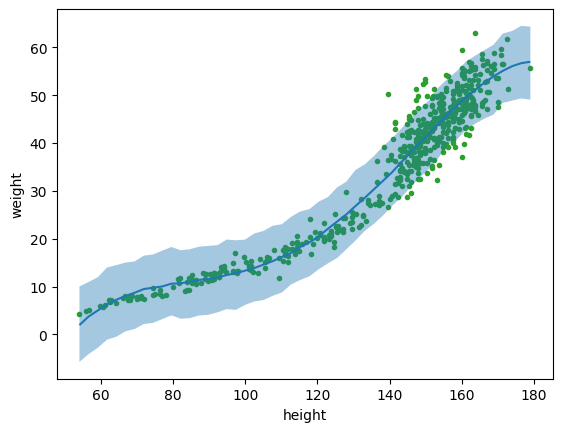

In [5]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly, idata_poly, "height", pps=True)
#raw data
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
#we need to specify the two distribution's relationships with a bambi method
model_formula = bmb.Formula(
    "weight ~ poly(height, degree=3)",
    "sigma ~ height"
)

model_polyvv = bmb.Model(model_formula, howell)

idata_dis = model_polyvv.fit(idata_kwargs={"log_likelihood":True})
##grabbed from unit 6 notes

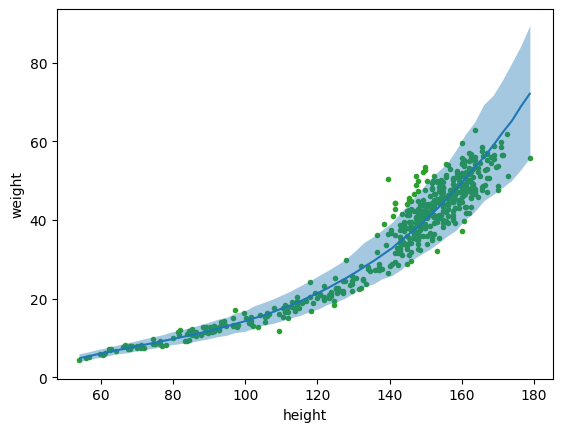

In [7]:
##plot of posterior predictive dist
bmb.interpret.plot_predictions(model_polyvv, idata_dis, "height", pps=True)
#raw data
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
num_knots = 6
min_height = howell['height'].min()
max_height = howell['height'].max()
knots = np.linspace(min_height, max_height, num_knots+2)[1:-1]
model_spline = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell,)
idata_spline = model_spline.fit()

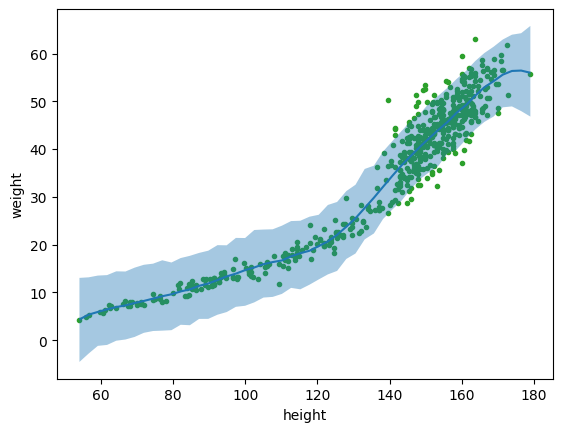

In [9]:
##plot of posterior predictive dist
bmb.interpret.plot_predictions(model_spline, idata_spline, "height", pps=True)
#raw data
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

(ik I should do vvariable variance for this one too but  running out of time)

In [10]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [11]:
m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[0, 24], lengthscale_range=[1, 30], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))

Recommended smallest number of basis vectors (m): 168
Recommended smallest scaling factor (c): 8.0


In [ ]:
with pm.Model() as model_hsgp:
    # Get the height and weight data
    height_data = howell.height.values
    weight_data = howell.weight.values

    # Prior for our smoothness parameter
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(height_data))

    # This is our kernel, which decides how our points relate to one another
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    # The 'm' and 'c' parameters below were calculated for an 'x_range=[0, 24]'.
    # For the 'howell.height' data, which ranges from ~54 to ~179, these values
    # may not be optimal and should ideally be re-calculated for the correct range.
    # For example:
    # m_new, c_new = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    #     x_range=[height_data.min(), height_data.max()], lengthscale_range=[1, 30], cov_func="ExpQuad"
    # )
    # gp = pm.gp.HSGP(m=[m_new], c=c_new, cov_func=cov)
    gp = pm.gp.HSGP(m=[168], c=8.0, cov_func=cov)

    # f is for function, as in the function we use to transform our data
    # X for GP prior usually expects a 2D array
    f = gp.prior('f', X=height_data[:, None])

    # Prior for the standard deviation of the Normal likelihood
    # Since 'weight' is continuous, Normal distribution is more appropriate than NegativeBinomial
    sigma = pm.HalfNormal('sigma', 1) # Using a HalfNormal prior for standard deviation

    # Likelihood
    # Assuming 'weight' is normally distributed around the GP function 'f'
    y = pm.Normal("y", mu=f, sigma=sigma, observed=weight_data)

    idata_hsgp = pm.sample()

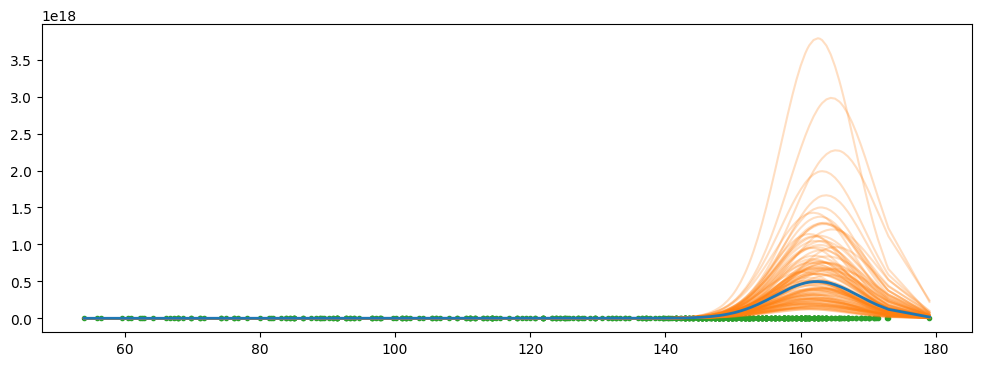

In [19]:
#set up plot
_, ax = plt.subplots(1, 1, figsize=(12, 4))
#plot raw data
ax.plot(howell["height"].values, howell["weight"].values, "C2.")

#grab posterior
f = az.extract(idata_hsgp, group="posterior", var_names="f")


idx = np.argsort(howell["height"].values)
#plot samples of the posterior
ax.plot(howell["height"].values[idx], np.exp(f.values[idx,:100]), alpha=0.25, color="C1")
#plot posterior mean
ax.plot(howell["height"].values[idx], np.exp(f.values[idx].mean(1)), color="C0", lw=2)

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

you can make a custom mean function piecewise style if you want to.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

I like the Posterior predictive check with the dark blue lines that fade to white as the density of the individual draws decreases. The variance of the variance is high, which is fun! It's predicting that co2 will decreas einto the 2000s which seems untrue to me, but I don't have time to read the rest of teh article very fully so. I see the later graph where the predicted CO2 shoots off up and I think that one makes more sense.